In [2]:
fig_num = 5 # change this to the figure number
analysis_name = "mpfc_alligned_response" # change this to the subfolder it should save to

In [3]:
%load_ext autoreload
%autoreload 2

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "9"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

# Define Data Files/Paths
subject = "wilbur"
date = "20210406"
file_name = subject + date
nwb_file_name = file_name + "_.nwb"

from spyglass.decoding.v1.c3po import Model
import matplotlib.pyplot as plt

if date == "20210404":
    marks_group_name = "mpfc1"
else:
    marks_group_name = "mpfc"
marks_group_name = "mpfc_HYBRID"

model_key = {
    "nwb_file_name": nwb_file_name,
    "marks_group_name": marks_group_name,
    "training_params_name":"wilbur_post_fix"
}
analysis = (Model() & model_key).fetch_c3po_analysis(model_key, checkpoint=6)


from c3po.analysis.analysis import figure_directory
from pathlib import Path
first_epochs = False
fig_dir = Path(figure_directory) / f"Fig{fig_num}/{analysis_name}"/f"{subject}_{date}_{marks_group_name}"
if first_epochs:
    fig_dir = fig_dir / f"first_{first_epochs}_epochs"
fig_dir.mkdir(parents=True, exist_ok=True)

/home/sambray/.local/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-10-02 09:24:51,104][INFO]: DataJoint 0.14.9 connected to sambray@lmf-db.cin.ucsf.edu:3306

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python

x shape (1, 34)
x shape (1, 32)


2026-10-02 09:25:10.246225: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-10-02 09:25:12.058010: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-10-02 09:25:14.177537: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
[2026-10-02 09:25:32,038][WARNING]: Skipped checksum for file

In [4]:
from spyglass.common import IntervalList
interval_query = IntervalList & (Model & model_key).proj(interval_list_name="training_interval_name")
run_epochs = interval_query.fetch1("valid_times")

if first_epochs:
    run_epochs = run_epochs[:first_epochs]
analysis.fit_context_pca(fit_intervals = run_epochs)

t_interp = [np.arange(start, end, 0.001) for start, end in run_epochs]
t_interp = np.concatenate(t_interp)
t_interp.shape
analysis.interpolate_context(t_interp)
analysis.embed_context_pca()

# Load Data

### Trial and decoding dataframes

In [5]:
from utils.load_mpfc_data import fetch_behavioral_data, fetch_dio_times, fetch_decoding_df

behave_df_set = fetch_behavioral_data(nwb_file_name)
trial_df = behave_df_set["trial_df"]
alison_df = behave_df_set["alison_df"]

dio_intervals = fetch_dio_times(nwb_file_name)
all_pump_intervals = dio_intervals["all_pump_intervals"]
all_poke_intervals = dio_intervals["all_poke_intervals"]

decoding_df = fetch_decoding_df(nwb_file_name)


[09:30:16][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: fetch_nwb (helper function)
	Use instead: table.fetch_nwb() method (logic integrated into FetchMixin)
[09:30:16][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: get_nwb_table
	Use instead: FetchMixin.fetch_nwb() (logic integrated into mixin)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older 

### Sorted Spikes

In [6]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

key = {"nwb_file_name": nwb_file_name}
spikes_query = SortedSpikesGroup() & key
spikes_key = spikes_query.fetch1("KEY")
spikes = (spikes_query).fetch_spike_data(spikes_key)

[09:31:24][WARNING] Spyglass: Missing code for CurationV2
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-pa

In [7]:
if "hybrid" in marks_group_name.lower():
    W = analysis.params["params"]["embedding"]["encoder"]["sorted_encoder"]["encoder_matrix"]
    z_neuron = W @ analysis.pca.components_.T
    z_mean = z_neuron.copy()

else:
    from c3po.tables.sorted_waveforms import EmbeddedSortedWaveform
    from c3po.analysis.intervals import interval_list_contains_ind

    sorted_df = (EmbeddedSortedWaveform & model_key).fetch_dataframe()
    z_neuron = []
    from tqdm import tqdm
    for z, z_times in tqdm(zip(sorted_df.z.values, sorted_df.spike_times.values)):
        ind = interval_list_contains_ind(run_epochs, z_times)
        z_mean = np.mean(z[ind], axis=0)
        z_neuron.append(z_mean @ analysis.pca.components_.T)
    sorted_df["z_neuron"] = z_neuron

# define trial motivation state

/tmp/ipykernel_22686/3517845751.py:11: RuntimeWarning: Mean of empty slice.
  trial_mot_pcs.append(analysis.c_pca_interp[ind_st:ind_en, mot_pcs].mean(axis=0))


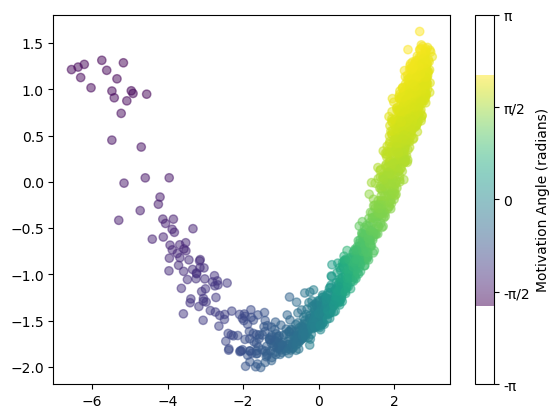

In [13]:
mot_pcs = (0,2)

z_neruon = analysis.params["params"]["embedding"]["encoder"]["sorted_encoder"]["encoder_matrix"] @ analysis.pca.components_.T

trial_mot_pcs = []
for trial in trial_df.itertuples():
    st = trial.run_start-.5
    en = trial.t_poke + .5
    ind_st = np.searchsorted(t_interp, st)
    ind_en = np.searchsorted(t_interp, en)
    trial_mot_pcs.append(analysis.c_pca_interp[ind_st:ind_en, mot_pcs].mean(axis=0))
trial_mot_pcs = np.array(trial_mot_pcs)
trial_mot_angle = np.arctan2(trial_mot_pcs[:,0], -trial_mot_pcs[:,1])
# plt.scatter(trial_mot_pcs[:,0], trial_mot_pcs[:,1], c=trial_df.prev_trial_reward, cmap=plt.cm.coolwarm, alpha=0.5)
trial_df["motivation"] = trial_mot_angle

plt.scatter(trial_mot_pcs[:,0], trial_mot_pcs[:,1], c=trial_mot_angle, alpha=0.5)
trial_df["motivation"] = trial_mot_angle
cb = plt.colorbar()
cb.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
cb.set_ticklabels(["-π", "-π/2", "0", "π/2", "π"])
cb.set_label("Motivation Angle (radians)")

# Aligned mean responses

### Select data Groupings

In [14]:
_df = trial_df.copy()
_df = _df[_df["n_pre_switch"] > 0]
compiled_groupings = {}

##########################
### Previous Reward
##########################
condition_type = "category"
condition_feature = "prev_trial_reward"
condition_values = _df[condition_feature].unique()
condition_values = condition_values[~np.isnan(condition_values)]
condition_groups = []
condition_labels = []
condition_colors = []

if condition_type == "category":
    for value in condition_values:
        condition_groups.append(_df[_df[condition_feature] == value])
        condition_labels.append(f"{condition_feature} = {value} \n(n = {len(condition_groups[-1])})")
        # condition_colors.append(f"C{len(condition_groups) - 1}")
        i_color = .1 if value == 0 else .9
        condition_colors.append(plt.cm.managua(i_color))


group_dict = dict(
    condition_groups = condition_groups,
    condition_labels = condition_labels,
    condition_colors = condition_colors,
    condition_feature = condition_feature
)

compiled_groupings[condition_feature] = group_dict

# ##########################
# ### Value Updates
# ##########################
condition_type = "range"
condition_feature = "motivation"

condition_values = np.linspace(-np.pi/4, np.nanmax(trial_df.motivation), 11) # FOR HEATMAPS
condition_values = np.linspace(-np.pi/4, np.nanmax(trial_df.motivation), 6) # FOR NEURON RATES

condition_groups = []
condition_labels = []
condition_colors = []
if condition_type == "range":
    for  prev_reward in [0, 1]:
        _df_category = _df[_df.prev_trial_reward == prev_reward]
        label_prefix = "Rewarded" if prev_reward == 1 else "Unrewarded"
        for i in range(len(condition_values) - 1):

            condition_groups.append(_df_category[
                (_df_category[condition_feature] >= condition_values[i])
                & (_df_category[condition_feature] < condition_values[i+1])
            ])
            condition_labels.append(
                f"{label_prefix}:\n"
                + f"Motivation: {condition_values[i]:.2f}, {condition_values[i+1]:.2f}\n"+
                f"(n = {len(condition_groups[-1])})")
            color = np.mean(condition_values[i:i+2])
            val_mids = (condition_values[1:] + condition_values[:-1]) / 2
            # color = color / np.max(np.abs(val_mids))
            # color += 1
            # color = color /2
            color = (color - np.min(val_mids)) / (np.max(val_mids) - np.min(val_mids))
            condition_colors.append(plt.cm.cool(color))

group_motivation_bins = condition_values.copy()
group_dict = dict(
    condition_groups = condition_groups,
    condition_labels = condition_labels,
    condition_colors = condition_colors,
    condition_feature = condition_feature
)

compiled_groupings["motivation_x_reward"] = group_dict

### Define Timing

In [10]:
mark_set = "B"

if mark_set == "A":
    mark_list = [ "run_start", "t_choice", "t_poke", ]
    offset_list = [ -.5, 1.25, 2.5, ]
    range_list = [ (-1, 1), (-0.5, 0.5), (-0.5, 1)]
elif mark_set == "B":
    mark_list = [ "run_start", "t_choice", ]
    offset_list = [ -.5, 1.25,  ]
    range_list = [ (-1, 1), (-0.5, 1),]
else:
    raise ValueError(f"mark_set {mark_set} not recognized. Must be 'A' or 'B'")

# mark_list = ["t_poke_prev",  "run_start", "t_choice", "t_poke", ]
# offset_list = [ -5, -.5, 1.25, 2.5, ]
# range_list = [(-1, 2), (-2, 1), (-0.5, 0.5), (-0.5, 1)]

### Calculate firing rates split by mean response

In [11]:
compiled_results = {m:[] for m in mark_list}
compiled_results_per_trial = {m:[] for m in mark_list}
compiled_values_per_trial = {m:[] for m in mark_list}
from scipy.ndimage import gaussian_filter1d

bin_size = 0.05
sig_smooth = 0.1

# group_dict = compiled_groupings['Q_leaf_A_update']
group_dict = compiled_groupings['motivation_x_reward']
condition_groups = group_dict['condition_groups']
condition_labels = group_dict['condition_labels']
condition_colors = group_dict['condition_colors']
condition_feature = group_dict['condition_feature']
from tqdm import tqdm
for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    for group, label, color in zip(condition_groups, condition_labels, condition_colors):
        t_bins_seg = np.arange(*range_val, bin_size)
        results = np.zeros((len(spikes), len(t_bins_seg) - 1))
        results_per_trial = np.zeros((len(spikes), len(t_bins_seg) - 1, len(group)))
        trial_marks = group[mark]
        for i_mark, m in enumerate(tqdm(trial_marks)):
            # rates = SortedSpikesGroup.get_firing_rate(spikes_key, t_bins_reward + m, smoothing_sigma=.01)
            # results.append(rates)
            for i, s in enumerate(spikes):
                st = np.searchsorted(s, m + t_bins_seg[0])
                en = np.searchsorted(s, m + t_bins_seg[-1])
                if en <= st:
                    continue
                delays = s[st:en] - m
                v = np.histogram(delays, bins=t_bins_seg)[0]

                v = v / (len(trial_marks) * bin_size)
                # v = smooth_signal(v, sig_smooth, bin_size)
                # v = gaussian_filter1d(v, sig_smooth/bin_size)
                results[i, :] += v
                results_per_trial[i, :, i_mark] = v
        results = np.array(results)
        results = gaussian_filter1d(results, sig_smooth/bin_size, axis=1)
        compiled_results[mark].append(results)
        compiled_results_per_trial[mark].append(results_per_trial)
        compiled_values_per_trial[mark].append(group[condition_feature].values)

run_start_rates = compiled_results['run_start']
mean_run_start_rate = np.array(run_start_rates).mean(axis=2).mean(axis=0)

100%|██████████| 255/255 [00:02<00:00, 119.98it/s]


## Big Plots

Text(0.5, 1.0, 'Rewarded')

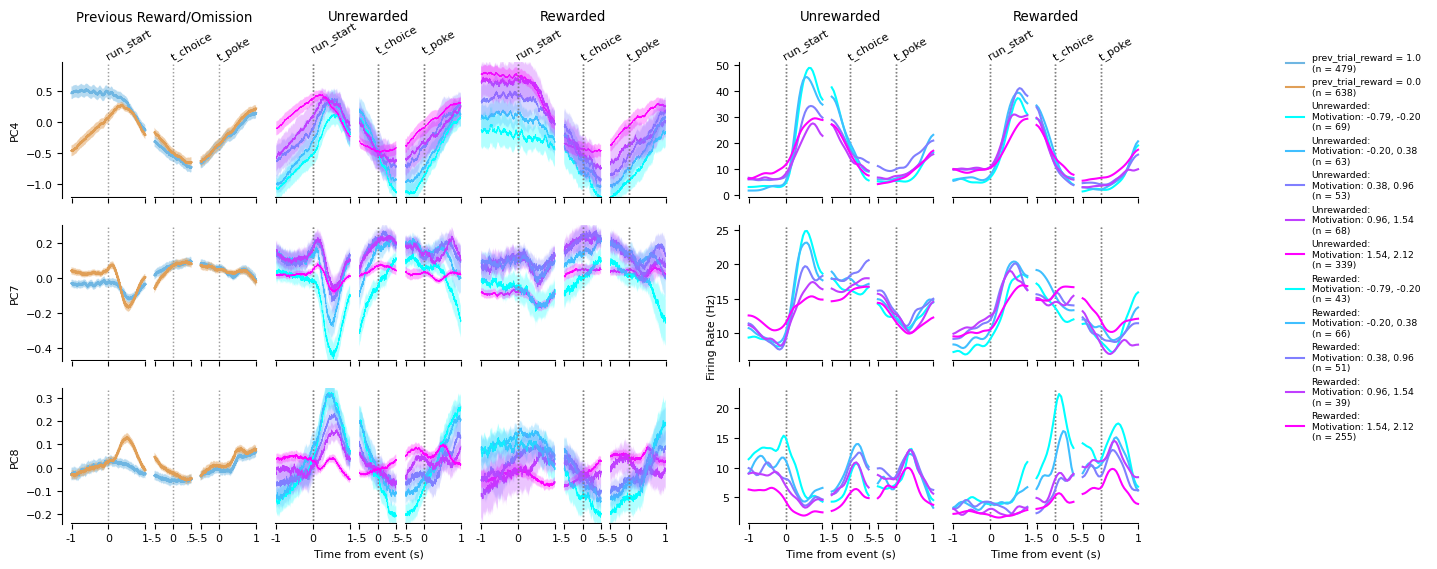

In [ ]:
pc_to_plot = [3,6,7,] # 11
neurons_to_plot = [2, 475, 8] #[2, 475, 182, 8]
show_dist = True
dist =  "sem" #"iqr"


width_ratios = [1, 1, 1, .3, 1, 1]
nrows = len(pc_to_plot)
# big_fig = plt.figure(figsize=(8.5,3))# 1.5 * nrows))
big_fig = plt.figure(figsize=(14,6))# 1.5 * nrows))
gs = big_fig.add_gridspec(
    nrows, 6,
    width_ratios=width_ratios
)
big_ax = np.empty((nrows, 5), dtype=object)
for i in range(nrows):
    # Grid columns 0, 1, 2
    big_ax[i, 0] = big_fig.add_subplot(
        gs[i, 0],
        sharex=big_ax[0, 0] if i > 0 else None
    )
    for j in range(1, 3):
        big_ax[i, j] = big_fig.add_subplot(
            gs[i, j],
            sharex=big_ax[0, 0],
            sharey=big_ax[i, 0]
        )
    # gs[i, 3] intentionally unused -> narrow spacer
    big_ax[i, 3] = big_fig.add_subplot(
        gs[i, 4],
        sharex=big_ax[0, 0]
    )
    big_ax[i, 4] = big_fig.add_subplot(
        gs[i, 5],
        sharex=big_ax[0, 0],
        sharey=big_ax[i, 3]
    )


plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 8
marker_line_kwargs = dict(
    color="grey",
    linestyle=":",
    linewidth=1,
    zorder=-1,
    alpha=0.5
)



#########################
### Previous Reward #####
#########################

ax_list = big_ax[:,0]
group_dict = compiled_groupings['prev_trial_reward']
condition_groups = group_dict['condition_groups']
condition_labels = group_dict['condition_labels']
condition_colors = group_dict['condition_colors']
condition_feature = group_dict['condition_feature']





reward_vals = [False, True]
reward_name = ["unrewarded", "rewarded"]

for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    for group, label, color in zip(condition_groups, condition_labels, condition_colors):
        # print(f"Processing {mark} for {label}")
        # for i_ax, (reward_val, reward_label) in enumerate(zip(reward_vals, reward_name)):
            # group = group_full[group_full.prev_trial_reward == reward_val]


        mark_times = group[mark].values
        if len(mark_times) == 0:
            continue
        results = analysis.alligned_response(mark_times, range_val, pca=True)
        # results = results[:, ::2]


        # mid = np.nanmedian(results, axis=0)
        # lo = np.nanpercentile(results, 25, axis=0)
        # hi = np.nanpercentile(results, 75, axis=0)

        if show_dist:
            if dist == "iqr":
                r = np.nanpercentile(results, [25, 50, 75], axis=0)
                mid = r[1]
                lo = r[0]
                hi = r[2]
            elif dist == "sem":
                mid = np.nanmean(results, axis=0)
                sem = np.nanstd(results, axis=0) / np.sqrt(np.sum(~np.isnan(results), axis=0)) * 3
                lo = mid - sem
                hi = mid + sem

        else:
            mid = np.nanmean(results, axis=0)


        t_plot = np.linspace(range_val[0], range_val[1], len(mid)) + offset
        ind_mid = np.digitize(offset,t_plot)
        for i, pc in enumerate(pc_to_plot):
            # pc = pc_to_plot[i]
            ax = ax_list[i]#[i_ax]
            ax.plot(t_plot,mid[:, pc], label=label if (mark == mark_list[0] and i ==0) else None, color=color)
            if show_dist:
                ax.fill_between(t_plot, lo[:, pc], hi[:, pc], facecolor=color, alpha=0.5)
            ax.axvline(offset, **marker_line_kwargs)


# ##########################
# ### Context values (Motivation x Reward)
# ##########################

ax_list = big_ax[:,1:3]

group_dict = compiled_groupings['motivation_x_reward']
condition_groups = group_dict['condition_groups']
condition_labels = group_dict['condition_labels']
condition_colors = group_dict['condition_colors']
condition_feature = group_dict['condition_feature']

reward_vals = [False, True]
reward_name = ["unrewarded", "rewarded"]

for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    for i_group, (group_full, label, color) in enumerate(zip(condition_groups, condition_labels, condition_colors)):
        # print(f"Processing {mark} for {label}")
        for i_ax, (reward_val, reward_label) in enumerate(zip(reward_vals, reward_name)):
            group = group_full[group_full.prev_trial_reward == reward_val]


            mark_times = group[mark].values
            if len(mark_times) == 0:
                continue
            results = analysis.alligned_response(mark_times, range_val, pca=True)
            if results.shape[0] <10:
                continue


            if show_dist:
                if dist == "iqr":
                    r = np.nanpercentile(results, [25, 50, 75], axis=0)
                    mid = r[1]
                    lo = r[0]
                    hi = r[2]
                elif dist == "sem":
                    mid = np.nanmean(results, axis=0)
                    sem = np.nanstd(results, axis=0) / np.sqrt(np.sum(~np.isnan(results), axis=0)) * 3
                    lo = mid - sem
                    hi = mid + sem
            else:
                mid = np.nanmean(results, axis=0)


            t_plot = np.linspace(range_val[0], range_val[1], len(mid)) + offset
            ind_mid = np.digitize(offset,t_plot)
            zorder = -i_group if reward_val else i_group
            for i, pc in enumerate(pc_to_plot):
                # pc = pc_to_plot[i]
                ax = ax_list[i][i_ax]
                label = None
                ax.plot(t_plot,mid[:, pc], label=label if (mark == mark_list[0] and i ==0) else None,
                        zorder=zorder, color=color, lw= .5)
                if show_dist:
                    ax.fill_between(t_plot, lo[:, pc], hi[:, pc], facecolor=color, alpha=0.3, zorder = -1)
                ax.axvline(offset, **marker_line_kwargs)



############################3
####### Context ylims
############################3


for i,pc in enumerate(pc_to_plot):
    for i_ax, ax in enumerate(ax_list[i]):
        ylim = ax.get_ylim()
        ylim_top = ylim[1] * .9#.2
        ylim_bottom = ylim[0] * .9

        ax.set_ylim(ylim_bottom, ylim_top)
        ylim = ax.get_ylim()

        if i ==0:
            for mark, offset in zip(mark_list, offset_list):
                # ax.text(offset + 0.05, ylim_top * 0.99, mark, ha="left", va="top", rotation=-90)
                 ax.text(offset - .1, ylim_top, mark, ha="left", va="bottom", rotation=30)

        ticks = []
        labels = []
        for mark, offset, rng in zip(mark_list, offset_list, range_list):
            lo = -1 if rng[0] < -.75 else rng[0]
            hi = 1 if rng[1] > 1 else rng[1]
            lo_txt = "-.5" if lo == -0.5 else "-1"
            hi_txt = ".5" if hi == 0.5 else "1"

            xx = np.array([lo, 0, hi])
            ticks.append(xx + offset)
            labels.append([lo_txt, "0", hi_txt])
            ax.plot(xx + offset, [ylim_bottom] * len(xx), color="k")
        ticks = np.concatenate(ticks)
        labels = np.concatenate(labels)
        ax.set_xticks(ticks, labels)

        ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
        ax.yaxis.set_visible(False)

    ax = big_ax[i,0]
    # ylim = ax.get_ylim()
    # ylim_top = ylim[1] * 1

    # ax.set_ylim(ylim[0],ylim_top)
    if i ==0:
        for mark, offset in zip(mark_list, offset_list):
            # ax.text(offset + 0.05, ylim_top * 0.99, mark, ha="left", va="top", rotation=-90)
            ax.text(offset -.1, ylim_top * 0.99, mark, ha="left", va="bottom", rotation=30)

    ticks = []
    labels = []
    for mark, offset, rng in zip(mark_list, offset_list, range_list):
        lo = -1 if rng[0] < -.75 else rng[0]
        hi = 1 if rng[1] > 1 else rng[1]
        lo_txt = "-.5" if lo == -0.5 else "-1"
        hi_txt = ".5" if hi == 0.5 else "1"

        xx = np.array([lo, 0, hi])
        ticks.append(xx + offset)
        labels.append([lo_txt, "0", hi_txt])
        ax.plot(xx + offset, [ylim_bottom] * len(xx), color="k")
        big_ax[i,1].plot(xx + offset, [ylim_bottom] * len(xx), color="k")
    ticks = np.concatenate(ticks)
    labels = np.concatenate(labels)
    ax.set_xticks(ticks, labels)

    ax.spines[["top", "right", "bottom"]].set_visible(False)


    ax.set_ylabel(f"PC{pc+1}")


# ##########################
# ###  Firing Rates (Value Updates)
# ##########################

# neurons_to_plot = [475,8, 182, 2]
# neurons_to_plot = [2, 475, 182, 8]
n_plot = len(neurons_to_plot)

ax_reward_list = big_ax[:, 4]
ax_unreward_list = big_ax[:,3]

# for i in range(n_plot):
#     fig, ax = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10, 2.5))
#     figure_list.append(fig)
#     ax_reward_list.append(ax[1])
#     ax_unreward_list.append(ax[0])

for i_group, (group, label, color,) in enumerate(zip(condition_groups, condition_labels, condition_colors, )):
    for mark, offset, range_val in zip(mark_list, offset_list, range_list, ):
        result = compiled_results[mark][i_group]

        t_plot = np.linspace(range_val[0], range_val[1], result.shape[1]) + offset
        ind_mid = np.digitize(offset,t_plot)
        for i, neuron in enumerate(neurons_to_plot):
            # ax = fig.gca()
            if group.prev_trial_reward.any():
                ax = ax_reward_list[i]
            else:
                ax = ax_unreward_list[i]
            ax.plot(
                t_plot,
                result[neurons_to_plot[i]],
                label=label if (mark == mark_list[0] and i == 0) else None,
                color=color,
                lw=1.5
            )
            # ax.fill_between(t_plot, lo[:,i], hi[:,i], facecolor=color, alpha=0.2)
            ax.axvline(offset, **marker_line_kwargs)

for i,pc in enumerate(neurons_to_plot):
    for j, ax in enumerate([ax_unreward_list[i], ax_reward_list[i]]):
        ylim = ax.get_ylim()
        ylim_top = ylim[1] * 1#.2
        ax.set_ylim(ylim[0], ylim_top)

        if i ==0:
            for mark, offset in zip(mark_list, offset_list):
                # ax.text(offset + 0.05, ylim_top * 0.99, mark, ha="left", va="top", rotation=-90)
                ax.text(offset - .1, ylim_top, mark, ha="left", va="bottom", rotation=30)
        ticks = []
        labels = []
        for mark, offset, rng in zip(mark_list, offset_list, range_list):
            lo = -1 if rng[0] < -.75 else rng[0]
            hi = 1 if rng[1] > 1 else rng[1]
            lo_txt = "-.5" if lo == -0.5 else "-1"
            hi_txt = ".5" if hi == 0.5 else "1"

            xx = np.array([lo, 0, hi])
            ticks.append(xx + offset)
            labels.append([lo_txt, "0", hi_txt])
            ax.plot(xx + offset, [ylim[0]] * len(xx), color="k")
        ticks = np.concatenate(ticks)
        labels = np.concatenate(labels)
        ax.set_xticks(ticks, labels)
        if i ==len(neurons_to_plot) - 1:
            ax.set_xlabel("Time from event (s)")

        ax.spines[["top", "right", "bottom"]].set_visible(False)
        # if j ==0:
        #     ax.set_ylabel("Firing Rate (Hz)")

for a in ax_reward_list:
    a.spines["left"].set_visible(False)
    a.yaxis.set_visible(False)

ax_unreward_list[1].set_ylabel("Firing Rate (Hz)",labelpad=-1, ha="right")


big_fig.legend(
    loc="outside right upper", fontsize="small", #title=condition_feature,
    bbox_to_anchor=(1.1, .9), borderaxespad=0., frameon=False
)

for a in np.ravel(big_ax[:-1, :]):
    a.tick_params(axis='x', labelbottom=False)

big_ax[-1,1].set_xlabel("Time from event (s)")
big_fig.subplots_adjust(wspace=.01)

pad = 30
big_ax[0,0].set_title("Previous Reward/Omission", pad=pad)
big_ax[0,1].set_title("Unrewarded", pad=pad)
big_ax[0,3].set_title("Unrewarded", pad=pad)
big_ax[0,4].set_title("Rewarded", pad=pad)
big_ax[0,2].set_title("Rewarded", pad=pad)
# big_fig.savefig(fig_dir / f"combined_pc_firing_rate_plot.svg")



NameError: name 'ax_unreward_list' is not defined

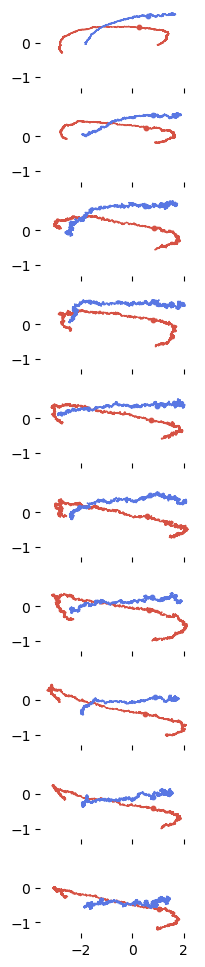

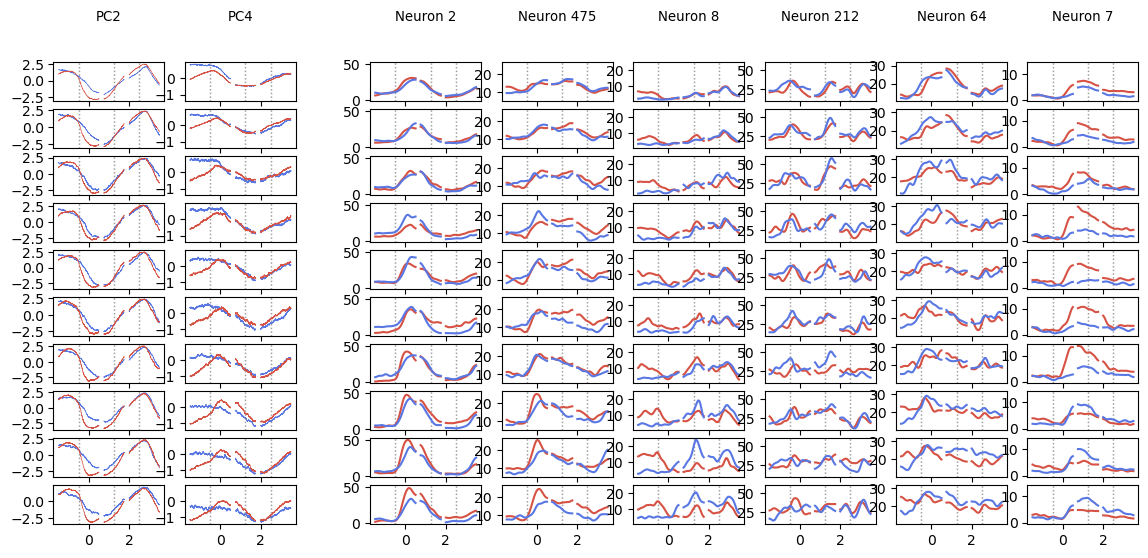

In [14]:
# Flip of big plot.
# Each column is a pc
# Each row is a different motivation level, both reward condition

pc_to_plot = [6,7,] # 3, 11
pc_2d = [6,7]

pc_to_plot = [1,3] # 3, 11
pc_2d = [1,3]

neurons_to_plot = [2, 475, 8, 212, 64, 7] #[2, 475, 182, 8]
show_dist = False
dist =  "sem" #"iqr"
flip_order = True


nrows = len(group_motivation_bins) -1
ncols = len(neurons_to_plot) + len(pc_to_plot)+1

fig_2d, ax_2d = plt.subplots(nrows=nrows,  figsize=(2, 12), sharex=True, sharey=True)
# big_fig, big_ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 6), sharex=True, sharey="col")

# big_fig = plt.figure(figsize=(8.5,3))# 1.5 * nrows))
width_ratios = [1] * len(pc_to_plot) + [0.3] + [1]* len(neurons_to_plot)
big_fig = plt.figure(figsize=(14,6))# 1.5 * nrows))
gs = big_fig.add_gridspec(
    nrows, ncols,
    width_ratios=width_ratios
)
big_ax = np.empty((nrows, ncols-1), dtype=object)
for i in range(nrows):
    # Grid columns 0, 1, 2
    big_ax[i, 0] = big_fig.add_subplot(
        gs[i, 0],
        sharex=big_ax[0, 0] if i > 0 else None
    )
    for j in range(1, len(pc_to_plot)):
        big_ax[i, j] = big_fig.add_subplot(
            gs[i, j],
            sharex=big_ax[0, 0],
            sharey=big_ax[0,j] if i > 0 else None
        )
    # gs[i, 3] intentionally unused -> narrow spacer
    # big_ax[i, ] = big_fig.add_subplot(
    #     gs[i, 4],
    #     sharex=big_ax[0, 0]
    # )
    # big_ax[i, 4] = big_fig.add_subplot(
    #     gs[i, 5],
    #     sharex=big_ax[0, 0],
    #     sharey=big_ax[i, 3]
    # )
    for k in range(len(neurons_to_plot)):
        big_ax[i, k + len(pc_to_plot)] = big_fig.add_subplot(
            gs[i, k + len(pc_to_plot) + 1],
            sharex=big_ax[0, 0],
            sharey=big_ax[0, k + len(pc_to_plot)] if i > 0 else None
        )



plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 8
marker_line_kwargs = dict(
    color="grey",
    linestyle=":",
    linewidth=1,
    zorder=-1,
    alpha=0.5
)


# ##########################
# ### Context values (Motivation x Reward)
# ##########################

ax_list = big_ax[:,:len(pc_to_plot)]

group_dict = compiled_groupings['motivation_x_reward']
condition_groups = group_dict['condition_groups']
condition_labels = group_dict['condition_labels']
condition_colors = group_dict['condition_colors']
condition_feature = group_dict['condition_feature']

reward_vals = [False, True]
reward_name = ["unrewarded", "rewarded"]

for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    for i_group, (group_full, label, color) in enumerate(zip(condition_groups, condition_labels, condition_colors)):
        # print(f"Processing {mark} for {label}")
        mot_sample = group_full[condition_feature].values[0]
        mot_ind = np.digitize(mot_sample, group_motivation_bins) - 1
        if flip_order:
            mot_ind = nrows - 1 - mot_ind
        for i_ax, (reward_val, reward_label) in enumerate(zip(reward_vals, reward_name)):
            color = plt.cm.coolwarm(.1) if reward_val else plt.cm.coolwarm(.9)
            group = group_full[group_full.prev_trial_reward == reward_val]


            mark_times = group[mark].values
            if len(mark_times) == 0:
                continue
            results = analysis.alligned_response(mark_times, range_val, pca=True)
            if results.shape[0] <10:
                continue


            if show_dist:
                if dist == "iqr":
                    r = np.nanpercentile(results, [25, 50, 75], axis=0)
                    mid = r[1]
                    lo = r[0]
                    hi = r[2]
                elif dist == "sem":
                    mid = np.nanmean(results, axis=0)
                    sem = np.nanstd(results, axis=0) / np.sqrt(np.sum(~np.isnan(results), axis=0)) * 3
                    lo = mid - sem
                    hi = mid + sem
            else:
                mid = np.nanmean(results, axis=0)


            t_plot = np.linspace(range_val[0], range_val[1], len(mid)) + offset
            ind_mid = np.digitize(offset,t_plot)
            zorder = -i_group if reward_val else i_group
            for i, pc in enumerate(pc_to_plot):
                # pc = pc_to_plot[i]
                # ax = ax_list[i][i_ax]
                ax = ax_list[mot_ind, i]
                label = None
                ax.plot(t_plot,mid[:, pc], label=label if (mark == mark_list[0] and i ==0) else None,
                        zorder=zorder, color=color, lw= .5)
                if show_dist:
                    ax.fill_between(t_plot, lo[:, pc], hi[:, pc], facecolor=color, alpha=0.3, zorder = -1)
                ax.axvline(offset, **marker_line_kwargs)

            if mark == "run_start":
                ax_2d[mot_ind].plot(mid[:, pc_2d[0]], mid[:, pc_2d[1]], color = color, lw = 1)
                ax_2d[mot_ind].scatter(mid[ind_mid, pc_2d[0]], mid[ind_mid, pc_2d[1]], color = color, s = 10)
                ax_2d[mot_ind].spines[["top", "right", "bottom", "left"]].set_visible(False)

for i,pc in enumerate(pc_to_plot):
    big_ax[0,i].set_title(f"PC{pc+1}", pad = 30)




# ##########################
# ###  Firing Rates (Value Updates)
# ##########################


n_plot = len(neurons_to_plot)


for i_group, (group, label, color,) in enumerate(zip(condition_groups, condition_labels, condition_colors, )):
    mot_sample = group[condition_feature].values[0]
    mot_ind = np.digitize(mot_sample, group_motivation_bins) - 1
    if flip_order:
        mot_ind = nrows - 1 - mot_ind
    for mark, offset, range_val in zip(mark_list, offset_list, range_list, ):
        result = compiled_results[mark][i_group]

        t_plot = np.linspace(range_val[0], range_val[1], result.shape[1]) + offset
        ind_mid = np.digitize(offset,t_plot)
        for i, neuron in enumerate(neurons_to_plot):
            # ax = fig.gca()
            if group.prev_trial_reward.any():
                # ax = ax_reward_list[i]
                color = plt.cm.coolwarm(.1)
            else:
                # ax = ax_unreward_list[i]
                color = plt.cm.coolwarm(.9)
            ax = big_ax[mot_ind, i + len(pc_to_plot)]
            ax.plot(
                t_plot,
                result[neurons_to_plot[i]],
                label=label if (mark == mark_list[0] and i == 0) else None,
                color=color,
                lw=1.5
            )
            # ax.fill_between(t_plot, lo[:,i], hi[:,i], facecolor=color, alpha=0.2)
            ax.axvline(offset, **marker_line_kwargs)

for i,pc in enumerate(neurons_to_plot):
    big_ax[0, i + len(pc_to_plot)].set_title(f"Neuron {pc}", pad = 30)


ax_unreward_list[1].set_ylabel("Firing Rate (Hz)",labelpad=-1, ha="right")


big_fig.legend(
    loc="outside right upper", fontsize="small", #title=condition_feature,
    bbox_to_anchor=(1.1, .9), borderaxespad=0., frameon=False
)

for a in np.ravel(big_ax[:, :]):
    a.spines[["top", "right", "bottom"]].set_visible(False)
    ylim = a.get_ylim()
    ticks = []
    labels = []
    for mark, offset, rng in zip(mark_list, offset_list, range_list):
        lo = -1 if rng[0] < -.75 else rng[0]
        hi = 1 if rng[1] > 1 else rng[1]
        lo_txt = "-.5" if lo == -0.5 else "-1"
        hi_txt = ".5" if hi == 0.5 else "1"

        xx = np.array([lo, 0, hi])
        ticks.append(xx + offset)
        labels.append([lo_txt, "0", hi_txt])
        a.plot(xx + offset, [ylim[0]] * len(xx), color="k")
    a.set_ylim(ylim)
    ticks = np.concatenate(ticks)
    labels = np.concatenate(labels)
    a.set_xticks(ticks, labels)

for a in big_ax[0,:]:
    ylim = a.get_ylim()
    for mark, offset in zip(mark_list, offset_list):
        a.text(offset - .1, ylim[1] * 0.99, mark, ha="left", va="bottom", rotation=30)
    a.set_ylim(ylim)

for a in np.ravel(big_ax[:-1, :]):
    a.tick_params(axis='x', labelbottom=False)

big_ax[-1,1].set_xlabel("Time from event (s)")



for i in range(nrows):
    if flip_order:
        ax = big_ax[nrows - 1 - i, 0]
    else:
        ax = big_ax[i, 0]
    color = condition_colors[i]
    ax.set_ylabel(f"Motivation: {group_motivation_bins[i]:.2f} - {group_motivation_bins[i+1]:.2f}",
                  labelpad=10,
                  color=color,
                  ha="right", rotation=0,
                  fontsize="10",
                  fontweight="bold"
                  )
big_ax[2, len(pc_to_plot)].set_ylabel("Firing Rate (Hz)",labelpad=5, ha="center")

## PCs Only

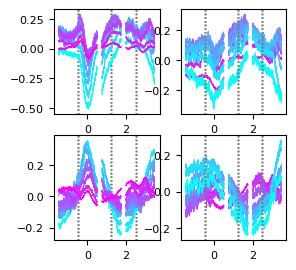

In [15]:
pc_to_plot  = [6,7]
show_dist = False

# ##########################
# ### Context values (Motivation x Reward)
# ##########################
n_rows = len(pc_to_plot)
marker_line_kwargs = dict(
    color="grey",
    linestyle=":",
    linewidth=1,
    zorder=-1,
    alpha=0.5
)
fig, ax_list = plt.subplots(nrows=n_rows, ncols=2, figsize=(3, 3))

group_dict = compiled_groupings['motivation_x_reward']
condition_groups = group_dict['condition_groups']
condition_labels = group_dict['condition_labels']
condition_colors = group_dict['condition_colors']
condition_feature = group_dict['condition_feature']

reward_vals = [False, True]
reward_name = ["unrewarded", "rewarded"]

for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    for i_group, (group_full, label, color) in enumerate(zip(condition_groups, condition_labels, condition_colors)):
        # print(f"Processing {mark} for {label}")
        for i_ax, (reward_val, reward_label) in enumerate(zip(reward_vals, reward_name)):
            group = group_full[group_full.prev_trial_reward == reward_val]


            mark_times = group[mark].values
            if len(mark_times) == 0:
                continue
            results = analysis.alligned_response(mark_times, range_val, pca=True)
            if results.shape[0] <10:
                continue


            if show_dist:
                if dist == "iqr":
                    r = np.nanpercentile(results, [25, 50, 75], axis=0)
                    mid = r[1]
                    lo = r[0]
                    hi = r[2]
                elif dist == "sem":
                    mid = np.nanmean(results, axis=0)
                    sem = np.nanstd(results, axis=0) / np.sqrt(np.sum(~np.isnan(results), axis=0)) * 3
                    lo = mid - sem
                    hi = mid + sem
            else:
                mid = np.nanmean(results, axis=0)


            t_plot = np.linspace(range_val[0], range_val[1], len(mid)) + offset
            ind_mid = np.digitize(offset,t_plot)
            zorder = -i_group if reward_val else i_group
            for i, pc in enumerate(pc_to_plot):
                # pc = pc_to_plot[i]
                ax = ax_list[i][i_ax]
                label = None
                ax.plot(t_plot,mid[:, pc], label=label if (mark == mark_list[0] and i ==0) else None,
                        zorder=zorder, color=color, lw= .5)
                if show_dist:
                    ax.fill_between(t_plot, lo[:, pc], hi[:, pc], facecolor=color, alpha=0.3, zorder = -1)
                ax.axvline(offset, **marker_line_kwargs)

## PC Diff Heatmap

In [13]:
pc_to_plot  = [6,7]


# ##########################
# ### Context values (Motivation x Reward)
# ##########################
n_rows = len(pc_to_plot)
marker_line_kwargs = dict(
    color="grey",
    linestyle=":",
    linewidth=1,
    zorder=-1,
    alpha=0.5
)

group_dict = compiled_groupings['motivation_x_reward']
condition_groups = group_dict['condition_groups']
condition_labels = group_dict['condition_labels']
condition_colors = group_dict['condition_colors']
condition_feature = group_dict['condition_feature']

reward_vals = [False, True]
reward_name = ["unrewarded", "rewarded"]


rewarded_heatmap = {m:[[] for _ in range(group_motivation_bins.size-1)] for m in mark_list}
unrewarded_heatmap = {m:[[] for _ in range(group_motivation_bins.size-1)] for m in mark_list}
for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    for i_group, (group_full, label, color) in enumerate(zip(condition_groups, condition_labels, condition_colors)):
        # print(f"Processing {mark} for {label}")
        for i_ax, (reward_val, reward_label) in enumerate(zip(reward_vals, reward_name)):
            group = group_full[group_full.prev_trial_reward == reward_val]


            mark_times = group[mark].values
            if len(mark_times) == 0:
                continue
            results = analysis.alligned_response(mark_times, range_val, pca=True)
            # if results.shape[0] <10:
            #     continue


            mid = np.nanmean(results, axis=0)

            mot_sample = group_full[condition_feature].values[0]
            mot_ind = np.digitize(mot_sample, group_motivation_bins) - 1
            if reward_val:
                rewarded_heatmap[mark][mot_ind]= mid
            else:
                unrewarded_heatmap[mark][mot_ind]= mid

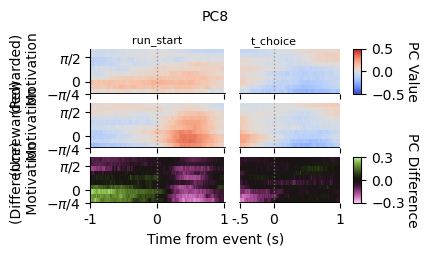

In [18]:
pc = 7


if mark_set == "A":
    figsize=(4,2)
elif mark_set == "B":
    figsize=(3.5,2)
else:
    raise ValueError(f"Unknown mark_set: {mark_set}")

fig, ax_list_all = plt.subplots(nrows=3, ncols=2, figsize=figsize, sharex='col', width_ratios=[30,1],
                                gridspec_kw=dict(wspace=0.1))
diff_cmap = "vanimo"
diff_lim = .3

ax_list = ax_list_all[:,0]
for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    h_reward = np.array(rewarded_heatmap[mark])
    h_unreward = np.array(unrewarded_heatmap[mark])

    ax = ax_list[:]
    xlim = offset + np.array(range_val)
    ax[0].matshow(h_reward[:,:,pc], aspect='auto', cmap='coolwarm', vmin=-0.5, vmax=0.5,
                extent=[xlim[0], xlim[1], group_motivation_bins[0], group_motivation_bins[-1]], origin='lower',
                rasterized=True)
    ax[1].matshow(h_unreward[:,:,pc], aspect='auto', cmap='coolwarm', vmin=-0.5, vmax=0.5,
                    extent=[xlim[0], xlim[1], group_motivation_bins[0], group_motivation_bins[-1]], origin='lower',
                    rasterized=True)

    reward_diff = h_reward[:,:,pc] - h_unreward[:,:,pc]
    ax[2].matshow(reward_diff, aspect='auto', cmap=diff_cmap, vmin=-diff_lim, vmax=diff_lim,
                    extent=[xlim[0], xlim[1], group_motivation_bins[0], group_motivation_bins[-1]], origin='lower')



marker_line_kwargs = {'color': 'grey', 'linestyle': ':', 'linewidth': 1, 'zorder': 1, 'alpha': 0.8}
ticks = []
labels = []
for mark, offset, range_val in zip(mark_list, offset_list, range_list):

    for i, a in enumerate(ax_list):
        a.axvline(offset, **marker_line_kwargs)
        # a.set_title(f"{mark} (PC{pc+1})" if i == 0 else None)
        # a.set_ylabel("Motivation")

        ylim = a.get_ylim()
        a.plot([offset + range_val[0], offset + range_val[1]], [ylim[0], ylim[0]], color='k', lw=2, zorder=3)
        a.set_ylim(ylim)

        if i == len(ax_list) - 1:
            a.set_xlabel("Time from event (s)")
for i,a in enumerate(np.ravel(ax_list)):
    a.spines[["top", "right", "bottom"]].set_visible(False)
    ylim = a.get_ylim()
    ticks = []
    labels = []
    for mark, offset, rng in zip(mark_list, offset_list, range_list):
        if i == 0:
            a.text(offset, ylim[1] * 1.05, mark, ha="center", va="bottom",fontsize=8)
        lo = -1 if rng[0] < -.75 else rng[0]
        hi = 1 if rng[1] > 1 else rng[1]
        lo_txt = "-.5" if lo == -0.5 else "-1"
        hi_txt = ".5" if hi == 0.5 else "1"

        xx = np.array([lo, 0, hi])
        ticks.extend(xx + offset)
        if i == len(ax_list) - 1:
            labels.extend([lo_txt, "0", hi_txt])
        else:
            labels.extend([""] * len(xx))

    a.set_xticks(ticks)
    a.set_xticklabels(labels)

    a.xaxis.tick_bottom()
    a.xaxis.set_label_position("bottom")

    a.set_yticks([-np.pi/4, 0, np.pi/2],[r"$-\pi/4$", "0", r"$\pi/2$"])

ax_list[0].set_xlim(offset_list[0] + range_list[0][0], offset_list[-1] + range_list[-1][1])

ax_list[0].set_ylabel("(Rewarded) \n Motivation")
ax_list[1].set_ylabel("(Unrewarded) \n Motivation")
ax_list[2].set_ylabel("(Difference) \n Motivation")
ax_list[0].set_title(f"PC{pc+1}", fontsize=10, pad=20)


cb1 = plt.colorbar(
    cax = ax_list_all[0,1],
    mappable=plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=-0.5, vmax=0.5)),
    orientation='vertical',
    label='PC Value'
)
cb1.set_ticks([-0.5, 0, 0.5])

ax_list_all[0,1].set_ylabel("PC Value", rotation=270, labelpad=10)
ax_list_all[1,1].set_visible(False)
cb2 = plt.colorbar(
    cax = ax_list_all[2,1],
    mappable=plt.cm.ScalarMappable(cmap=diff_cmap, norm=plt.Normalize(vmin=-diff_lim, vmax=diff_lim)),
    orientation='vertical',
    label='PC Difference'
)
cb2.set_ticks([-diff_lim, 0, diff_lim])
ax_list_all[2,1].set_ylabel("PC Difference", rotation=270, labelpad=10)

fig.savefig(fig_dir / f"rewarded_unrewarded_heatmap_mark_set{mark_set}_pc{pc+1}.svg", bbox_inches='tight', dpi=300)

# Neurons only, split be motivation and reward

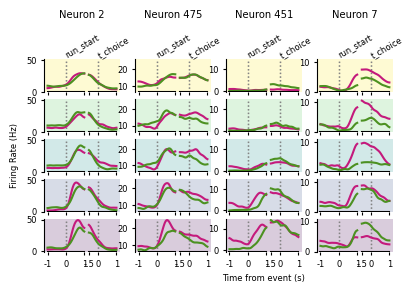

In [ ]:

neurons_to_plot = [2, 475, 8, 212, 64, 7] # 8
neurons_to_plot=[2, 475, 451, 7]
flip_order = True

n_plot = len(neurons_to_plot)
nrows = len(group_motivation_bins) -1
ncols = len(neurons_to_plot)
fig, big_ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4.5,2.5), sharex=True, sharey="col")
plt.rcParams['font.size'] = 6

for i_group, (group, label, color,) in enumerate(zip(condition_groups, condition_labels, condition_colors, )):
    mot_sample = group[condition_feature].values[0]
    mot_ind = np.digitize(mot_sample, group_motivation_bins) - 1
    if flip_order:
        mot_ind = nrows - 1 - mot_ind
    for mark, offset, range_val in zip(mark_list, offset_list, range_list, ):
        result = compiled_results[mark][i_group]

        t_plot = np.linspace(range_val[0], range_val[1], result.shape[1]) + offset
        ind_mid = np.digitize(offset,t_plot)
        for i, neuron in enumerate(neurons_to_plot):
            # ax = fig.gca()
            if group.prev_trial_reward.any():
                # ax = ax_reward_list[i]
                # color = plt.cm.coolwarm(.1)
                color = plt.cm.PiYG(.9)
            else:
                # ax = ax_unreward_list[i]
                # color = plt.cm.coolwarm(.9)
                color = plt.cm.PiYG(.1)
            ax = big_ax[mot_ind, i]
            ax.plot(
                t_plot,
                result[neurons_to_plot[i]],
                label=label if (mark == mark_list[0] and i == 0) else None,
                color=color,
                lw=1.5
            )
            # ax.fill_between(t_plot, lo[:,i], hi[:,i], facecolor=color, alpha=0.2)
            ax.axvline(offset, **marker_line_kwargs)

for i,pc in enumerate(neurons_to_plot):
    big_ax[0, i].set_title(f"Neuron {pc}", pad = 30)


# ax_unreward_list[1].set_ylabel("Firing Rate (Hz)",labelpad=-1, ha="right")


# big_fig.legend(
#     loc="outside right upper", fontsize="small", #title=condition_feature,
#     bbox_to_anchor=(1.1, .9), borderaxespad=0., frameon=False
# )

for a in np.ravel(big_ax[:, :]):
    a.spines[["top", "right", "bottom"]].set_visible(False)
    ylim = a.get_ylim()
    ticks = []
    labels = []
    for mark, offset, rng in zip(mark_list, offset_list, range_list):
        lo = -1 if rng[0] < -.75 else rng[0]
        hi = 1 if rng[1] > 1 else rng[1]
        lo_txt = "-.5" if lo == -0.5 else "-1"
        hi_txt = ".5" if hi == 0.5 else "1"

        xx = np.array([lo, 0, hi])
        ticks.append(xx + offset)
        labels.append([lo_txt, "0", hi_txt])
        a.plot(xx + offset, [ylim[0]] * len(xx), color="k")
    a.set_ylim(ylim)
    ticks = np.concatenate(ticks)
    labels = np.concatenate(labels)
    a.set_xticks(ticks, labels)

for a in big_ax[0,:]:
    ylim = a.get_ylim()
    for mark, offset in zip(mark_list, offset_list):
        a.text(offset - .1, ylim[1] * 0.99, mark, ha="left", va="bottom", rotation=30)
    a.set_ylim(ylim)

for a in np.ravel(big_ax[:-1, :]):
    a.tick_params(axis='x', labelbottom=False)

big_ax[-1,n_plot//2].set_xlabel("Time from event (s)")



for i in range(nrows):
    if flip_order:
        ax = big_ax[nrows - 1 - i, 0]
    else:
        ax = big_ax[i, 0]
    color = plt.cm.viridis(i / (nrows - 1))
    row = i if not flip_order else nrows - 1 - i
    for a in big_ax[row,:]:
        a.set_facecolor(color)
        a.patch.set_alpha(0.2)
    # color = condition_colors[i]
    # ax.set_ylabel(f"Motivation: {group_motivation_bins[i]:.2f} - {group_motivation_bins[i+1]:.2f}",
    #               labelpad=10,
    #               color=color,
    #               ha="right", rotation=0,
    #               fontsize="10",
    #               fontweight="bold"
    #               )

        a.tick_params(axis="x", which="major", length=2, width=0.8)
        a.tick_params(axis="y", which="major", length=2, width=0.8)
big_ax[2, 0].set_ylabel("Firing Rate (Hz)",labelpad=5, ha="center")
fig.savefig(fig_dir / f"rewarded_unrewarded_firing_rate_mark_set{mark_set}.svg", bbox_inches='tight', dpi=300)

## Test Neurons

(array([ 2.,  3.,  9.,  9.,  8., 14., 14.,  9., 20., 16., 22., 24., 21.,
        14., 23., 15., 23., 24., 19., 17., 20., 13., 17., 10.,  8., 12.,
        20., 13.,  5., 11.,  8.,  8.,  8.,  3.,  8.,  4.,  6.,  2.,  4.,
         5.,  0.,  1.,  0.,  1.,  0.,  3.,  0.,  0.,  0.,  1.]),
 array([0.00464041, 0.011232  , 0.01782358, 0.02441517, 0.03100675,
        0.03759833, 0.04418992, 0.0507815 , 0.05737309, 0.06396467,
        0.07055626, 0.07714784, 0.08373943, 0.09033102, 0.0969226 ,
        0.10351418, 0.11010577, 0.11669736, 0.12328894, 0.12988052,
        0.13647211, 0.14306369, 0.14965527, 0.15624686, 0.16283844,
        0.16943003, 0.17602162, 0.18261319, 0.18920478, 0.19579637,
        0.20238794, 0.20897953, 0.21557112, 0.22216271, 0.2287543 ,
        0.23534587, 0.24193746, 0.24852905, 0.25512061, 0.26171219,
        0.26830378, 0.27489537, 0.28148696, 0.28807855, 0.2946701 ,
        0.30126169, 0.30785328, 0.31444487, 0.32103646, 0.32762805,
        0.33421963]),
 <BarContainer

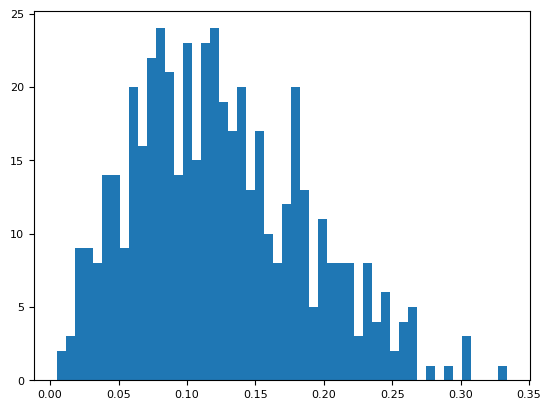

In [ ]:
pc_set = [6,7]
z_mag = np.linalg.norm(z_neuron[:, pc_set], axis=1)

plt.hist(z_mag, bins = 50)

In [ ]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

key = {"nwb_file_name": nwb_file_name}
spikes_query = SortedSpikesGroup() & key
spikes_key = spikes_query.fetch1("KEY")
spikes, unit_ids = (spikes_query).fetch_spike_data(spikes_key, return_unit_ids=True)
unit_ids = np.array([f"{u['spikesorting_merge_id']}_{u['unit_id']}" for u in unit_ids])

[15:42:14][WARNING] Spyglass: Missing code for CurationV2


In [ ]:
import os
os.chdir("/home/sambray/Documents/spyglass_custom/src/spyglass_custom/sambray")
from monosynaptic import Monosynaptic
from cross_correlogram import CrossCorrelogram, ShuffleCrossCorrelogram


# mono_key = (Monosynaptic & spikes_key).fetch1("KEY")
# neuron_types = (Monosynaptic & mono_key).get_neuron_types()
# mono_df = (Monosynaptic & mono_key).fetch1_dataframe()

# corr_df = (CrossCorrelogram & spikes_key & {"cross_corr_params_name":"monosynaptic"}).fetch1_dataframe()
# shuffle_corr_df = (ShuffleCrossCorrelogram & spikes_key).fetch1_dataframe()
# corr_df = corr_df.merge(shuffle_corr_df, on=["unit_id_1", "unit_id_2"], suffixes=("", "_shuffle"))
ind_neuron_type = {}
for type_, ids_ in neuron_types.items():
    ind_neuron_type[type_] = [np.where(unit_ids == i)[0][0] for i in ids_]
neuron_colors = {
    "excitatory": "cornflowerblue",
    "inhibitory":"firebrick"
}

In [ ]:
len(ind_neuron_type['inhibitory'])

25



In [ ]:
neurons_to_plot = [475,8, 182, 2]


pc = 7
ind_valid = np.where(mean_run_start_rate > 3)[0]
# ind_candidate = np.where(z_neuron[:,7]<.2)[0]
ind_candidate = np.argsort(-np.abs(z_neuron[ind_valid,pc]))[:50]
ind_candidate = ind_valid[ind_candidate]
neurons_to_plot = ind_candidate[:50]

pc_set = [6,7]
z_mag = np.linalg.norm(z_neuron[:, pc_set], axis=1)
ind_valid = np.where(mean_run_start_rate > 0)[0]
ind_candidate = np.argsort(-np.abs(z_mag[ind_valid]))[:30]
neurons_to_plot = ind_valid[ind_candidate]

neurons_to_plot = ind_neuron_type['excitatory'][-50:]


n_plot = len(neurons_to_plot)

fig, big_ax = plt.subplots(nrows=n_plot, ncols=2, sharey='row', figsize=(10, 2.5 * n_plot))

ax_reward_list = big_ax[:, 1]
ax_unreward_list = big_ax[:,0]

# for i in range(n_plot):
#     fig, ax = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10, 2.5))
#     figure_list.append(fig)
#     ax_reward_list.append(ax[1])
#     ax_unreward_list.append(ax[0])

for i_group, (group, label, color,) in enumerate(zip(condition_groups, condition_labels, condition_colors, )):
    for mark, offset, range_val in zip(mark_list, offset_list, range_list, ):
        result = compiled_results[mark][i_group]

        t_plot = np.linspace(range_val[0], range_val[1], result.shape[1]) + offset
        ind_mid = np.digitize(offset,t_plot)
        for i, neuron in enumerate(neurons_to_plot):
            # ax = fig.gca()
            if group.prev_trial_reward.all():
                ax = ax_reward_list[i]
            elif (not group.prev_trial_reward.any()):
                ax = ax_unreward_list[i]
            else:
                raise ValueError("Group has mixed reward values, cannot determine which axis to plot on.")
            ax.plot(
                t_plot,
                result[neurons_to_plot[i]],
                label=label if (mark == mark_list[0] and i == 0) else None,
                color=color,
                lw=2,
                # label = label if i == 0 and mark == mark_list[0] else None
            )
            # ax.fill_between(t_plot, lo[:,i], hi[:,i], facecolor=color, alpha=0.2)
            ax.axvline(offset, **marker_line_kwargs)

for i,pc in enumerate(neurons_to_plot):
    ax_reward_list[i].set_ylabel(f"Neuron {pc}")
    for j, ax in enumerate([ax_unreward_list[i], ax_reward_list[i]]):
        ylim = ax.get_ylim()
        ylim_top = ylim[1] * 1#.2
        ax.set_ylim(ylim[0], ylim_top)

        if i ==0:
            for mark, offset in zip(mark_list, offset_list):
                # ax.text(offset + 0.05, ylim_top * 0.99, mark, ha="left", va="top", rotation=-90)
                ax.text(offset - .1, ylim_top, mark, ha="left", va="bottom", rotation=30)
        ticks = []
        labels = []
        for mark, offset, rng in zip(mark_list, offset_list, range_list):
            lo = -1 if rng[0] < -.75 else rng[0]
            hi = 1 if rng[1] > 1 else rng[1]
            lo_txt = "-.5" if lo == -0.5 else "-1"
            hi_txt = ".5" if hi == 0.5 else "1"

            xx = np.array([lo, 0, hi])
            ticks.append(xx + offset)
            labels.append([lo_txt, "0", hi_txt])
            ax.plot(xx + offset, [ylim[0]] * len(xx), color="k")
        ticks = np.concatenate(ticks)
        labels = np.concatenate(labels)
        ax.set_xticks(ticks, labels)
        if i ==len(neurons_to_plot) - 1:
            ax.set_xlabel("Time from event (s)")

        ax.spines[["top", "right", "bottom"]].set_visible(False)
        # if j ==0:
        #     ax.set_ylabel("Firing Rate (Hz)")

for a in ax_reward_list:
    a.spines["left"].set_visible(False)
    # a.yaxis.set_visible(False)

ax_unreward_list[1].set_ylabel("Firing Rate (Hz)",labelpad=-1, ha="right")
ax_unreward_list[0].set_title("Unrewarded Trials", pad=30)
ax_reward_list[0].set_title("Rewarded Trials", pad=30)

fig.legend(
    frameon=False,
    bbox_to_anchor=(.9, 1), loc="upper left", fontsize="small"
)


# 'critical window'

In [ ]:
# mark = "run_start"
# t_window = (.4,.7)

# data = np.array(compiled_results[mark])

# range_val = range_list[mark_list.index(mark)]
# t_plot = np.linspace(*range_val,data.shape[2])
# ind_wind = np.where((t_plot >= t_window[0]) & (t_plot <= t_window[1]))[0]
# data = data[:,:,ind_wind]
# data = data.mean(axis=2)

# mot_ind = []
# reward = []
# for i_group, (group, label, color,) in enumerate(zip(condition_groups, condition_labels, condition_colors, )):
#     mot_sample = group[condition_feature].values[0]
#     mot_ind.append(np.digitize(mot_sample, group_motivation_bins) - 1)
#     reward.append(group.prev_trial_reward.values[0])

# ind_sort =np.argsort(mot_ind)
# data = data[ind_sort]
# mot_ind = np.array(mot_ind)[ind_sort]
# reward = np.array(reward)[ind_sort]

# data_rewarded = data[reward.astype(bool)]
# data_unrewarded = data[~reward.astype(bool)]

# data_ratio = data_rewarded / (data_unrewarded + 1e-6)
# data_ratio = np.log2(data_ratio)

# # data_ratio = data_rewarded - data_unrewarded

# lim = 10

# ind_sort = np.argsort(z_neuron[:,8])
# data_ratio = data_ratio[:,ind_sort]
# plt.matshow(data_ratio.T, aspect="auto", cmap="coolwarm", vmin=-lim, vmax=lim)


In [ ]:
data_ratio.shape

(5, 497)

# Decodability of reward vs Motivation state

In [ ]:
motivation_bins = np.linspace(-np.pi/4, np.nanmax(trial_df.motivation), 6)
decode_df_list = []
_df = trial_df.copy()
_df = _df[_df["n_pre_switch"] > 0]
for i in range(len(motivation_bins) - 1):
    ind = (_df.motivation >= motivation_bins[i]) & (_df.motivation < motivation_bins[i+1])
    decode_df_list.append(_df[ind].copy())
motivation_bin_centers = (motivation_bins[1:] + motivation_bins[:-1]) / 2
motivation_colors = plt.cm.cool((motivation_bin_centers - np.min(motivation_bin_centers)) / (np.max(motivation_bin_centers) - np.min(motivation_bin_centers)))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from scipy.stats import zscore

decode_feature = "prev_trial_reward"


step_size = 0.02
window_size = 0.125


mark_list = [ "run_start", "t_choice", "t_poke", ]
offset_list = [ -1, .75, 2., ]
range_list = [ (-1, 1), (-0.5, 0.5), (-0.5, 1)]



decode_df_list = [df[~np.isnan(df[decode_feature].values)] for df in decode_df_list]
results_all = []
r2_all = []
auc_all = []

for _df in decode_df_list:
    results = {m:[] for m in mark_list}
    r2 = {m:[] for m in mark_list}
    auc = {m:[] for m in mark_list}

    for mark, offset, range_val in zip(mark_list, offset_list, range_list):
        for window_shift in tqdm(np.arange(range_val[0], range_val[1]+1e-4, step_size)):
            results_window = []
            r2_window = []


            vals = _df[mark].values + window_shift
            ind_vals = np.logical_and(vals > analysis.t_interp[0], vals < analysis.t_interp[-1])
            _df_i = _df[ind_vals]


            marks_i = _df_i[mark].values + window_shift
            context_i = analysis.alligned_response(marks_i, (-window_size, window_size), pca=True).mean(axis=1)
            context_i = zscore(context_i, axis=0)

            y = _df_i[decode_feature].values
            decode = LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")
            decode.fit(context_i, y)
            y_pred = decode.predict_proba(context_i)[:, 1]
            auc_i = roc_auc_score(y, y_pred)
            auc[mark].append(auc_i)
            # context_i = zscore(context_i, axis=0)

    #         from sklearn.linear_model import LinearRegression
    #         from sklearn.metrics import r2_score
    #         decode_ = LinearRegression()
    #         y = _df_i[decode_feature].values
    #         # y = zscore(y)
    #         decode = decode_.fit(context_i, y)
    #         coef_i = decode.coef_
    #         y_pred = decode.predict(context_i)
    #         # r2_i = [r2_score(y[:, j], y_pred[:, j]) for j in range(y.shape[1])]
    #         r2_i = r2_score(y, y_pred)
    #         results_window.append(coef_i)
    #         r2_window.append(r2_i)
    #         results[mark].append(results_window)
    #         r2[mark].append(r2_window)
    #         # break

    # results_all.append(results)
    # r2_all.append(r2)
    auc_all.append(auc)




100%|██████████| 76/76 [00:06<00:00, 11.01it/s]


{'run_start': [0.9898887765419615, 0.9875294910684193, 0.9865183687226153, 0.9851702055948769, 0.9844961240310077, 0.9831479609032693, 0.9841590832490731, 0.9865183687226154, 0.9885406134142232, 0.9925851027974385, 0.9949443882709808, 0.9959555106167846, 0.9966295921806538, 0.9932591843613077, 0.9929221435793731, 0.9915739804516347, 0.9919110212335693, 0.9905628581058309, 0.9882035726322885, 0.9868554095045501, 0.9855072463768115, 0.985170205594877, 0.9858442871587463, 0.9882035726322885, 0.989551735760027, 0.9915739804516346, 0.9935962251432423, 0.9929221435793731, 0.9915739804516346, 0.9912369396697001, 0.9919110212335692, 0.9925851027974385, 0.9929221435793731, 0.9925851027974385, 0.9919110212335693, 0.9922480620155039, 0.9912369396697, 0.9908998988877653, 0.989551735760027, 0.9912369396697001, 0.9905628581058308, 0.9915739804516347, 0.9915739804516347, 0.9915739804516347, 0.9929221435793731, 0.9919110212335693, 0.993933265925177, 0.9952814290529154, 0.9966295921806538, 0.9976407145

/tmp/ipykernel_1091384/2099132829.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc="upper right", fontsize="small", title="Decoded Feature",bbox_to_anchor=(1.3, 1),


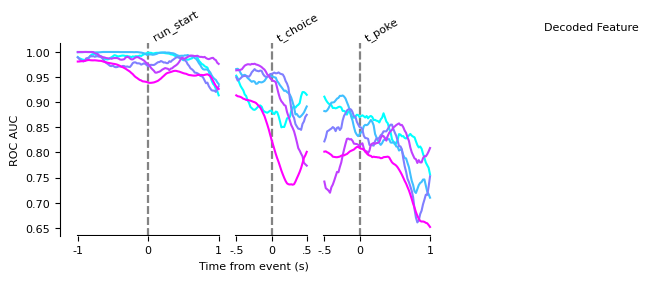

In [ ]:


fig, ax = plt.subplots(figsize=(5, 2.5),nrows=1,sharex="col",
                       ncols=1)
r2_ax = ax

min_val = 0
max_val = 0

for i, auc in enumerate(auc_all):
    color = motivation_colors[i]
    print(auc)
    for mark, offset, range_val in zip(mark_list, offset_list, range_list):
        auc_i = np.array(auc[mark])
        # results_i = np.array(results[mark])

        t_plot = np.linspace(range_val[0], range_val[1], len(auc_i))+offset
        # min_val = min(min_val, t_plot.min())
        # max_val = max(max_val, t_plot.max())


        r2_ax.plot(t_plot, auc_i,color=color, label = label)
        r2_ax.axvline(offset, color="grey", linestyle="--", zorder=-1, alpha=0.5)
        # cb = coef_ax.imshow(results_i.T, aspect="auto", extent=[t_plot[0], t_plot[-1], results_i.shape[1],0], origin="upper",
        #                     cmap = "RdBu", vmin=-v_rng, vmax=v_rng, )

# plt.colorbar(cb, cax=cbar_ax)
# coef_ax.set_xlim(min_val, max_val)


for a in [ax]:
    ylim = a.get_ylim()
    ylim_top = ylim[1] * 1
    a.set_ylim(ylim[0], ylim_top)

    for mark, offset in zip(mark_list, offset_list):
        a.text(offset + 0.05, ylim_top * 1, mark, ha="left", va="bottom", rotation=30)
        # a.

    ticks = []
    labels = []
    for mark, offset, rng in zip(mark_list, offset_list, range_list):
        lo = -1 if rng[0] < -.75 else rng[0]
        hi = 1 if rng[1] > 1 else rng[1]
        lo_txt = "-.5" if lo == -0.5 else "-1"
        hi_txt = ".5" if hi == 0.5 else "1"

        xx = np.array([lo, 0, hi])
        ticks.append(xx + offset)
        labels.append([lo_txt, "0", hi_txt])
        a.plot(xx + offset, [ylim[0]] * len(xx), color="k")
    ticks = np.concatenate(ticks)
    labels = np.concatenate(labels)
    a.set_xticks(ticks, labels)
    a.set_xlabel("Time from event (s)")

    a.spines[["top", "right", "bottom"]].set_visible(False)
    # fig.legend(loc="outside right upper", fontsize="small", title=condition_feature)

    a.set_ylabel("Firing Rate (Hz)")
    # fig.suptitle(f"Neuron {neurons_to_plot[pc]} (PC angle = {z_angle[neurons_to_plot[pc]]:.2f})")

r2_ax.set_ylabel("ROC AUC")
fig.legend(loc="upper right", fontsize="small", title="Decoded Feature",bbox_to_anchor=(1.3, 1),
           frameon=False, borderpad=0.5, labelspacing=0.5, handletextpad=0.5, handlelength=1.5)


# fig.savefig(fig_dir / f"dynamic_decoding_value_updates.svg", bbox_inches="tight")
# fig.savefig(fig_dir / f"dynamic_decoding_n_post_switch.svg", bbox_inches="tight")

# modulation of avg trial firing rate

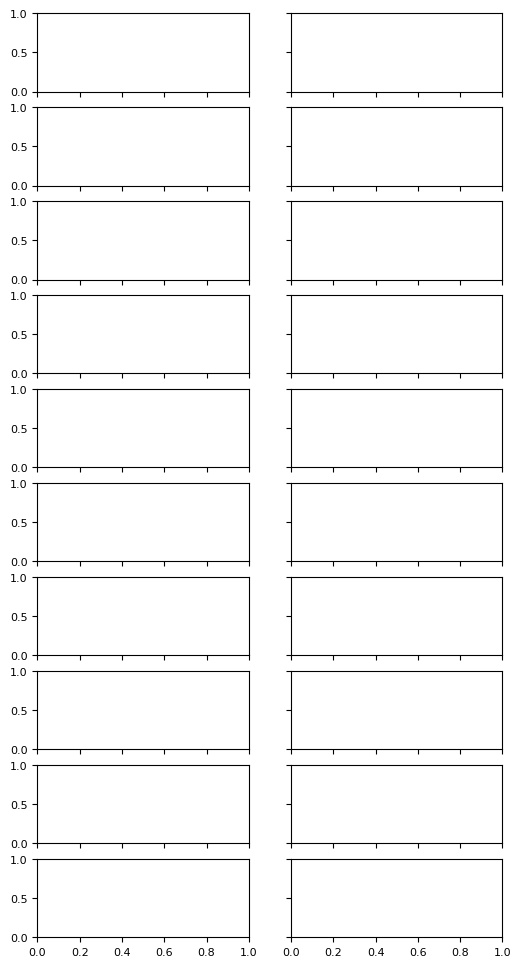

In [ ]:
# pc_set = [6,7]
# mot_thresh = -.1

# z_mag = np.linalg.norm(z_neuron[:, pc_set], axis=1)
# z_angle = np.arctan2(z_neuron[:, pc_set[1]], z_neuron[:, pc_set[0]])

# thresh = .1
# ind = np.where(z_mag > thresh)[0]
# ind_sorted = ind[np.argsort(z_angle[ind])]

# data = compiled_results_per_trial["run_start"]
# data_all =np.concatenate(data,axis=2)
# mean_response = np.nanmean(data_all, axis=2)


# # for i,pc in enumerate(pc_to_plot):
# n_rows = len(group_motivation_bins) - 1
# ncols=2
# fig, ax = plt.subplots(nrows=n_rows, ncols=ncols, figsize=(6, 12), sharex=True, sharey=True)
# for i_group, (group, label, color,) in enumerate(zip(condition_groups, condition_labels, condition_colors, )):
#     # for mark, offset, range_val in zip(mark_list, offset_list, range_list, ):
#     mot_sample = group[condition_feature].values[0]
#     mot_ind = np.digitize(mot_sample, group_motivation_bins) - 1
#     if flip_order:
#         mot_ind = n_rows - 1 - mot_ind
#     reward_val = int(group.prev_trial_reward.values[0])
#     mark = "run_start"
#     result = compiled_results[mark][i_group]

#     delta = result - mean_response

#     ax[mot_ind, reward_val].imshow(delta[ind_sorted])

In [ ]:
delta.shape

# Sample trial sequences

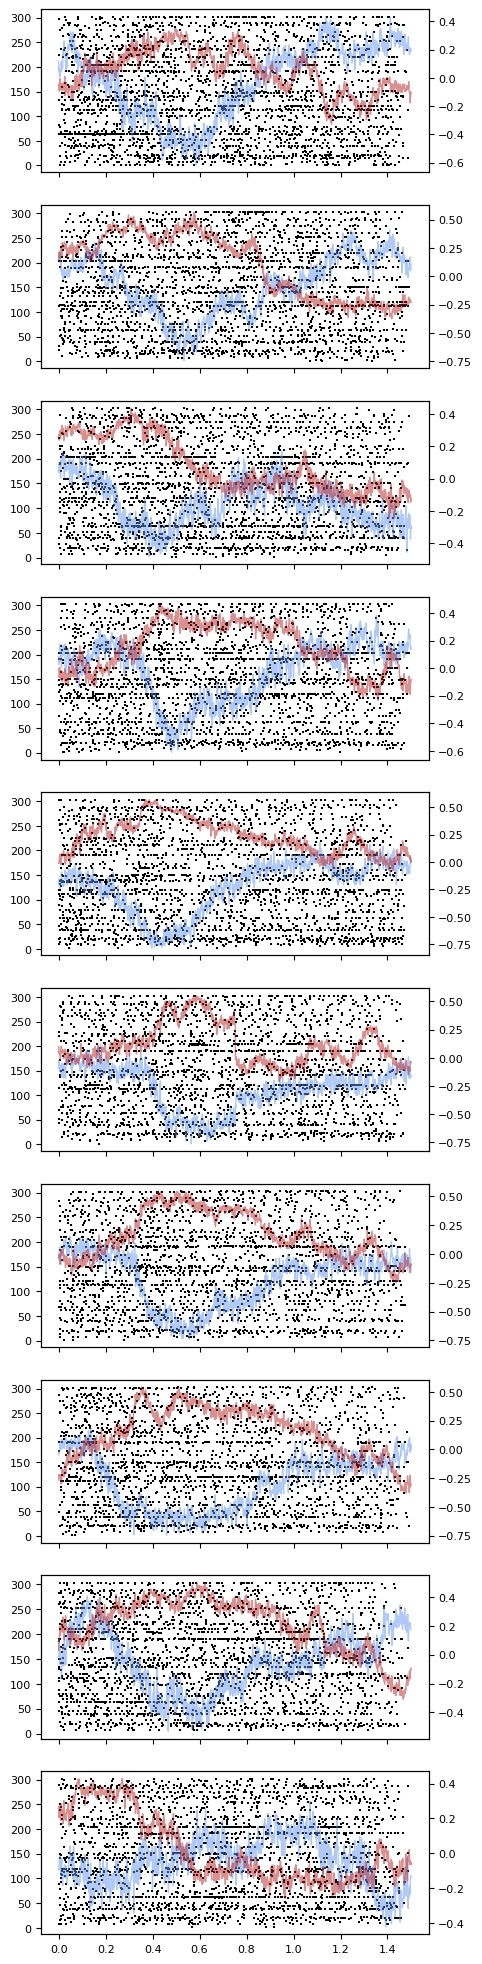

In [ ]:
pc_set = [6,7]
mot_thresh = -.1


z_mag = np.linalg.norm(z_neuron[:, pc_set], axis=1)
z_angle = np.arctan2(z_neuron[:, pc_set[1]], z_neuron[:, pc_set[0]])

thresh = .1
ind = np.where(z_mag > thresh)[0]
ind_sorted = ind[np.argsort(z_angle[ind])]

_df = trial_df.copy()
_df = trial_df.copy()
_df = _df[_df["n_pre_switch"] > 0]
_df = _df[_df["motivation"] < mot_thresh]
_df = _df[_df.motivation > group_motivation_bins[0]]
_df = _df[_df.prev_trial_reward == 0]



# z_neuron.shape
n_samples = 10
ind = np.random.permutation(len(_df))[:10]
_df = _df.iloc[ind]
fig, ax = plt.subplots(figsize=(5, 2.5*n_samples),nrows=n_samples,sharex="col",)

for i, (_, row) in enumerate(_df.iterrows()):
    if i >= n_samples:
        break
    xx =[]
    yy = []
    for j, neuron in enumerate(ind_sorted):
        mark = "run_start"
        offset = -1
        range_val = (0, 1.5)

        st = np.digitize(row[mark] +range_val[0], spikes[neuron])
        en = np.digitize(row[mark] +range_val[1], spikes[neuron]) - 1
        spikes_i = spikes[neuron][st:en]
        yy_i = np.ones(len(spikes_i)) * j
        xx.extend(spikes_i - row[mark])
        yy.extend(yy_i)
        # ax[i].scatter(spikes_i - row[mark], yy, color="k", s=1)
        # ax.axvline(offset, color="grey", linestyle="--", zorder=-1, alpha=0.5)
        # ax.axvline(0, color="grey", linestyle
    ax[i].scatter(xx, yy, color="k", marker="|", s=1, zorder=20)
    ax_c = ax[i].twinx()
    mid = analysis.alligned_response(np.array([row[mark]]), range_val, pca=True).mean(axis=0)
    t_plot = np.linspace(range_val[0], range_val[1], len(mid))
    ax_c.plot(t_plot, mid[:, pc_set[0]], color="cornflowerblue", lw=1, zorder=-1, alpha = 0.5)
    ax_c.plot(t_plot, mid[:, pc_set[1]], color="firebrick", lw=1, zorder=-1, alpha = 0.5)
    # break

In [ ]:
row[mark]

1617736805.5511742

# Focused Sequence Identification

In [ ]:
group_motivation_bins
mot_thresh = 0
mark = "run_start"
window = (0,1)

_df = trial_df.copy()
_df = _df[_df["n_pre_switch"] > 0]
_df = _df[_df["motivation"] < mot_thresh]
_df = _df[_df.prev_trial_reward == 0]

st = _df[mark].values
fit_interval = np.array([st + window[0], st + window[1]]).T

analysis_local = analysis.copy()
analysis_local.fit_context_pca(fit_interval,)
# analysis_local.embed_context_pca()


# analysis_local =

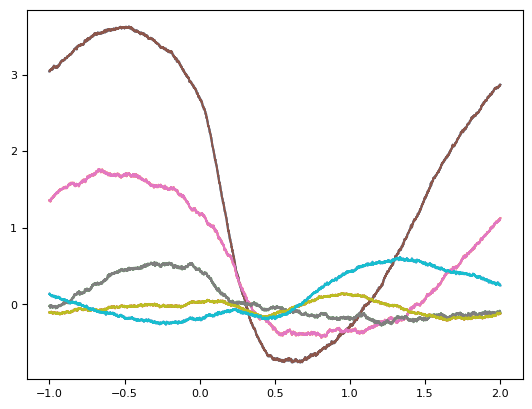

In [ ]:
mark = "run_start"
window = (-1,2)

result = analysis_local.alligned_response(_df[mark].values, window, pca=True)
mid = np.nanmean(result, axis=0)

t_plot = np.linspace(window[0], window[1], mid.shape[0])
plt.plot(t_plot, mid[:, :5], label = "PC6")
plt.plot(t_plot, mid[:, :5], label = "PC7")


/tmp/ipykernel_1091384/3850928115.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  big_fig.legend(


IndexError: index 7 is out of bounds for axis 1 with size 7

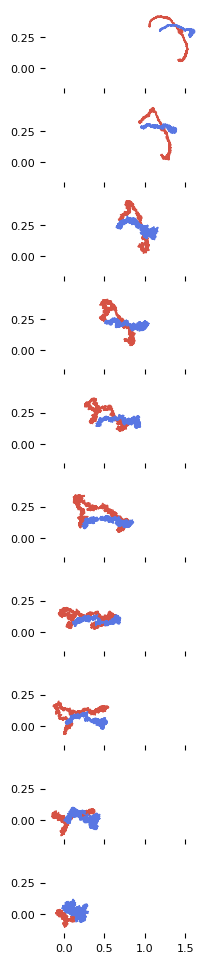

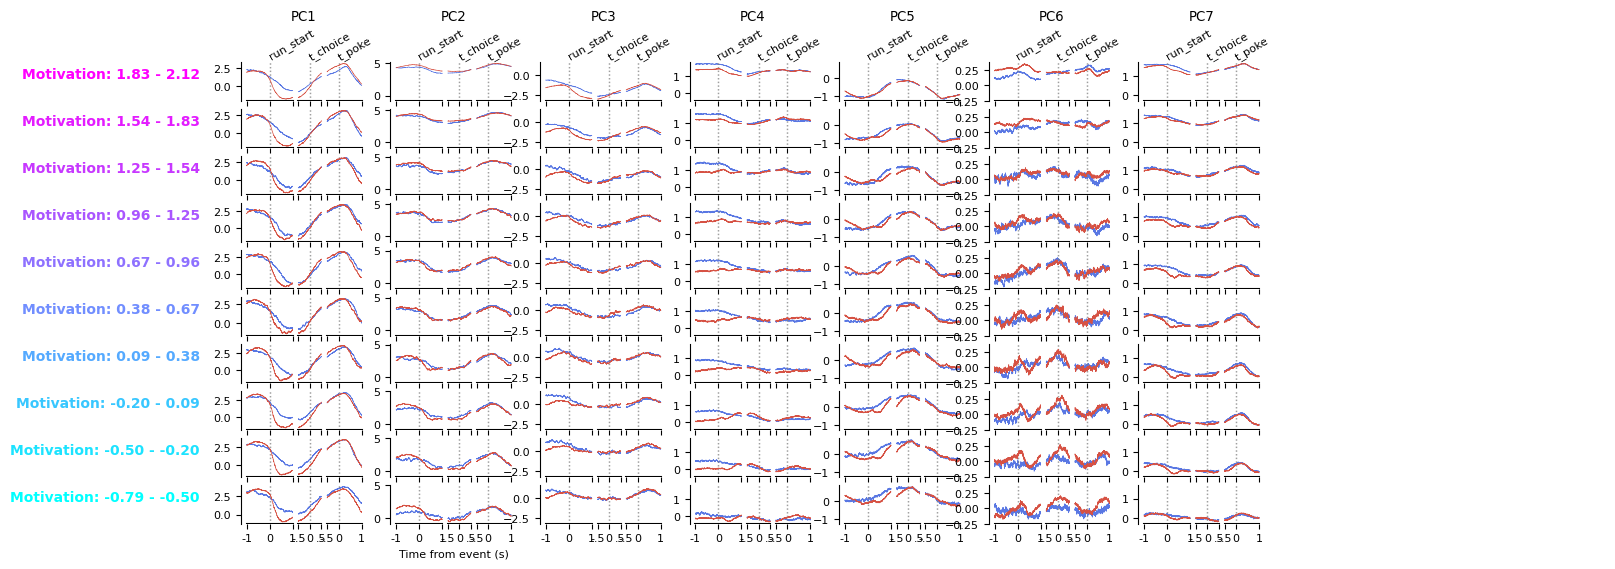

In [ ]:
# Flip of big plot.
# Each column is a pc
# Each row is a different motivation level, both reward condition

pc_to_plot = np.arange(7)
pc_2d = [6,7]

neurons_to_plot = []#2, 475, 8, 212, 64, 7] #[2, 475, 182, 8]
show_dist = False
dist =  "sem" #"iqr"
flip_order = True


nrows = len(group_motivation_bins) -1
ncols = len(neurons_to_plot) + len(pc_to_plot)+1

fig_2d, ax_2d = plt.subplots(nrows=nrows,  figsize=(2, 12), sharex=True, sharey=True)
# big_fig, big_ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 6), sharex=True, sharey="col")

# big_fig = plt.figure(figsize=(8.5,3))# 1.5 * nrows))
width_ratios = [1] * len(pc_to_plot) + [0.3] + [1]* len(neurons_to_plot)
big_fig = plt.figure(figsize=(14,6))# 1.5 * nrows))
gs = big_fig.add_gridspec(
    nrows, ncols,
    width_ratios=width_ratios
)
big_ax = np.empty((nrows, ncols-1), dtype=object)
for i in range(nrows):
    # Grid columns 0, 1, 2
    big_ax[i, 0] = big_fig.add_subplot(
        gs[i, 0],
        sharex=big_ax[0, 0] if i > 0 else None
    )
    for j in range(1, len(pc_to_plot)):
        big_ax[i, j] = big_fig.add_subplot(
            gs[i, j],
            sharex=big_ax[0, 0],
            sharey=big_ax[0,j] if i > 0 else None
        )
    # gs[i, 3] intentionally unused -> narrow spacer
    # big_ax[i, ] = big_fig.add_subplot(
    #     gs[i, 4],
    #     sharex=big_ax[0, 0]
    # )
    # big_ax[i, 4] = big_fig.add_subplot(
    #     gs[i, 5],
    #     sharex=big_ax[0, 0],
    #     sharey=big_ax[i, 3]
    # )
    for k in range(len(neurons_to_plot)):
        big_ax[i, k + len(pc_to_plot)] = big_fig.add_subplot(
            gs[i, k + len(pc_to_plot) + 1],
            sharex=big_ax[0, 0],
            sharey=big_ax[0, k + len(pc_to_plot)] if i > 0 else None
        )



plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 8
marker_line_kwargs = dict(
    color="grey",
    linestyle=":",
    linewidth=1,
    zorder=-1,
    alpha=0.5
)


# ##########################
# ### Context values (Motivation x Reward)
# ##########################

ax_list = big_ax[:,:len(pc_to_plot)]

group_dict = compiled_groupings['motivation_x_reward']
condition_groups = group_dict['condition_groups']
condition_labels = group_dict['condition_labels']
condition_colors = group_dict['condition_colors']
condition_feature = group_dict['condition_feature']

reward_vals = [False, True]
reward_name = ["unrewarded", "rewarded"]

for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    for i_group, (group_full, label, color) in enumerate(zip(condition_groups, condition_labels, condition_colors)):
        # print(f"Processing {mark} for {label}")
        mot_sample = group_full[condition_feature].values[0]
        mot_ind = np.digitize(mot_sample, group_motivation_bins) - 1
        if flip_order:
            mot_ind = nrows - 1 - mot_ind
        for i_ax, (reward_val, reward_label) in enumerate(zip(reward_vals, reward_name)):
            color = plt.cm.coolwarm(.1) if reward_val else plt.cm.coolwarm(.9)
            group = group_full[group_full.prev_trial_reward == reward_val]


            mark_times = group[mark].values
            if len(mark_times) == 0:
                continue
            results = analysis_local.alligned_response(mark_times, range_val, pca=True)
            if results.shape[0] <10:
                continue


            if show_dist:
                if dist == "iqr":
                    r = np.nanpercentile(results, [25, 50, 75], axis=0)
                    mid = r[1]
                    lo = r[0]
                    hi = r[2]
                elif dist == "sem":
                    mid = np.nanmean(results, axis=0)
                    sem = np.nanstd(results, axis=0) / np.sqrt(np.sum(~np.isnan(results), axis=0)) * 3
                    lo = mid - sem
                    hi = mid + sem
            else:
                mid = np.nanmean(results, axis=0)


            t_plot = np.linspace(range_val[0], range_val[1], len(mid)) + offset
            ind_mid = np.digitize(offset,t_plot)
            zorder = -i_group if reward_val else i_group
            for i, pc in enumerate(pc_to_plot):
                # pc = pc_to_plot[i]
                # ax = ax_list[i][i_ax]
                ax = ax_list[mot_ind, i]
                label = None
                ax.plot(t_plot,mid[:, pc], label=label if (mark == mark_list[0] and i ==0) else None,
                        zorder=zorder, color=color, lw= .5)
                if show_dist:
                    ax.fill_between(t_plot, lo[:, pc], hi[:, pc], facecolor=color, alpha=0.3, zorder = -1)
                ax.axvline(offset, **marker_line_kwargs)

            if mark == "run_start":
                ax_2d[mot_ind].plot(mid[:, pc_2d[0]], mid[:, pc_2d[1]], color = color, lw = 1)
                ax_2d[mot_ind].scatter(mid[ind_mid, pc_2d[0]], mid[ind_mid, pc_2d[1]], color = color, s = 10)
                ax_2d[mot_ind].spines[["top", "right", "bottom", "left"]].set_visible(False)

for i,pc in enumerate(pc_to_plot):
    big_ax[0,i].set_title(f"PC{pc+1}", pad = 30)




# ##########################
# ###  Firing Rates (Value Updates)
# ##########################


n_plot = len(neurons_to_plot)


for i_group, (group, label, color,) in enumerate(zip(condition_groups, condition_labels, condition_colors, )):
    mot_sample = group[condition_feature].values[0]
    mot_ind = np.digitize(mot_sample, group_motivation_bins) - 1
    if flip_order:
        mot_ind = nrows - 1 - mot_ind
    for mark, offset, range_val in zip(mark_list, offset_list, range_list, ):
        result = compiled_results[mark][i_group]

        t_plot = np.linspace(range_val[0], range_val[1], result.shape[1]) + offset
        ind_mid = np.digitize(offset,t_plot)
        for i, neuron in enumerate(neurons_to_plot):
            # ax = fig.gca()
            if group.prev_trial_reward.any():
                # ax = ax_reward_list[i]
                color = plt.cm.coolwarm(.1)
            else:
                # ax = ax_unreward_list[i]
                color = plt.cm.coolwarm(.9)
            ax = big_ax[mot_ind, i + len(pc_to_plot)]
            ax.plot(
                t_plot,
                result[neurons_to_plot[i]],
                label=label if (mark == mark_list[0] and i == 0) else None,
                color=color,
                lw=1.5
            )
            # ax.fill_between(t_plot, lo[:,i], hi[:,i], facecolor=color, alpha=0.2)
            ax.axvline(offset, **marker_line_kwargs)

for i,pc in enumerate(neurons_to_plot):
    big_ax[0, i + len(pc_to_plot)].set_title(f"Neuron {pc}", pad = 30)


ax_unreward_list[1].set_ylabel("Firing Rate (Hz)",labelpad=-1, ha="right")


big_fig.legend(
    loc="outside right upper", fontsize="small", #title=condition_feature,
    bbox_to_anchor=(1.1, .9), borderaxespad=0., frameon=False
)

for a in np.ravel(big_ax[:, :]):
    a.spines[["top", "right", "bottom"]].set_visible(False)
    ylim = a.get_ylim()
    ticks = []
    labels = []
    for mark, offset, rng in zip(mark_list, offset_list, range_list):
        lo = -1 if rng[0] < -.75 else rng[0]
        hi = 1 if rng[1] > 1 else rng[1]
        lo_txt = "-.5" if lo == -0.5 else "-1"
        hi_txt = ".5" if hi == 0.5 else "1"

        xx = np.array([lo, 0, hi])
        ticks.append(xx + offset)
        labels.append([lo_txt, "0", hi_txt])
        a.plot(xx + offset, [ylim[0]] * len(xx), color="k")
    a.set_ylim(ylim)
    ticks = np.concatenate(ticks)
    labels = np.concatenate(labels)
    a.set_xticks(ticks, labels)

for a in big_ax[0,:]:
    ylim = a.get_ylim()
    for mark, offset in zip(mark_list, offset_list):
        a.text(offset - .1, ylim[1] * 0.99, mark, ha="left", va="bottom", rotation=30)
    a.set_ylim(ylim)

for a in np.ravel(big_ax[:-1, :]):
    a.tick_params(axis='x', labelbottom=False)

big_ax[-1,1].set_xlabel("Time from event (s)")



for i in range(nrows):
    if flip_order:
        ax = big_ax[nrows - 1 - i, 0]
    else:
        ax = big_ax[i, 0]
    color = condition_colors[i]
    ax.set_ylabel(f"Motivation: {group_motivation_bins[i]:.2f} - {group_motivation_bins[i+1]:.2f}",
                  labelpad=10,
                  color=color,
                  ha="right", rotation=0,
                  fontsize="10",
                  fontweight="bold"
                  )
big_ax[2, len(pc_to_plot)].set_ylabel("Firing Rate (Hz)",labelpad=5, ha="center")